<a href="https://colab.research.google.com/github/47294/game_theory_course_spring2026/blob/main/network_attack/jax_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Классификация сетевых атак с помощью нейронной сети на JAX

---

В этом ноутбуке мы пройдём путь от основ функционального программирования до построения полноценной нейронной сети для обнаружения сетевых атак. Мы будем использовать **JAX** — библиотеку от Google, которая позволяет писать высокопроизводительный числовой код в функциональном стиле.

### Содержание

1. **Введение в функциональное программирование**
2. **JAX: философия и подход «Думай в JAX»**
3. **Forward vs Reverse mode дифференцирования**
4. **Предобработка данных**
5. **Нейронная сеть и инициализация весов**
6. **Батчевый градиентный спуск, метрики, мониторинг**
7. **Оптимизатор Adam на чистом JAX**
8. **Борьба с переобучением: регуляризация, dropout, ранняя остановка**

In [1]:
# Установка необходимых библиотек (раскомментируйте при необходимости)
!pip install jax jaxlib pandas scikit-learn matplotlib

---
## 1. Введение в функциональное программирование

Прежде чем погружаться в JAX, важно понять **функциональную парадигму**, потому что JAX построен именно на ней.

### Ключевые принципы

| Принцип | Описание |
|---------|----------|
| **Чистые функции** | Функция всегда возвращает одинаковый результат для одинаковых аргументов. Нет побочных эффектов. |
| **Иммутабельность** | Данные не изменяются — вместо этого создаются новые версии. |
| **Функции высшего порядка** | Функции могут принимать другие функции как аргументы и возвращать функции. |
| **Композиция** | Сложные операции строятся из простых функций, как конвейер. |

### Почему это важно для JAX?

JAX требует **чистоту функций** для корректной работы трансформаций (`jit`, `grad`, `vmap`). Если функция имеет побочные эффекты (например, изменяет глобальную переменную), JAX не сможет правильно её скомпилировать или продифференцировать.

In [2]:
# ============================================================
# Примеры функционального программирования на Python
# ============================================================

# --- Чистая функция ---
# Всегда возвращает одинаковый результат для одинаковых аргументов.
# Нет побочных эффектов (не меняет ничего «снаружи»).
def add(a, b):
    return a + b

print("Чистая функция:", add(2, 3))  # Всегда 5

# --- НЕчистая функция (побочный эффект) ---
counter = 0
def increment():
    global counter  # Изменяем внешнее состояние — это побочный эффект!
    counter += 1
    return counter
print("Нечистая функция:", increment(), increment())  # Разные результаты!

# --сделаем чистой
def increment(counter):
    return counter+1

counter = 0
counter = increment(increment(counter))
print(f'counter={counter}')

# --- Функция высшего порядка ---
# Принимает функцию как аргумент
def apply_twice(func, x):
    return func(func(x))

def double(x):
    return x * 2

print("Функция высшего порядка:", apply_twice(double, 3))  # double(double(3)) = 12

# --- Иммутабельность ---
# Вместо изменения списка создаём новый
original = [1, 2, 3]
new_list = [x * 2 for x in original]  # Новый список, original не изменён
print(f"Оригинал: {original}, Новый: {new_list}")

# --- Композиция функций ---
# Строим сложную операцию из простых
def compose(f, g):
    """Создаёт композицию: compose(f, g)(x) = f(g(x))"""
    return lambda x: f(g(x))

def square(x):
    return x ** 2

double_then_square = compose(square, double)
print("Композиция (2*3)^2 =", double_then_square(3))  # (2*3)^2 = 36

Чистая функция: 5
Нечистая функция: 1 2
counter=2
Функция высшего порядка: 12
Оригинал: [1, 2, 3], Новый: [2, 4, 6]
Композиция (2*3)^2 = 36


---
## 2. JAX: философия и подход «Думай в JAX»

**JAX** — это NumPy на стероидах + автоматическое дифференцирование + JIT-компиляция через XLA.

### Основные трансформации JAX

| Трансформация | Что делает |
|--------------|------------|
| `jax.grad` | Автоматическое дифференцирование — вычисляет градиент функции |
| `jax.jit` | Just-In-Time компиляция — ускоряет код через XLA |
| `jax.vmap` | Автоматическая векторизация — применяет функцию к батчу данных |
| `jax.pmap` | Параллелизация на нескольких устройствах (GPU/TPU) |

### Как «думать в JAX»

1. **Массивы иммутабельны.** В JAX нельзя написать `arr[0] = 5`. Вместо этого: `arr = arr.at[0].set(5)` — это создаёт **новый** массив.
2. **Функции должны быть чистыми.** Никаких глобальных переменных, побочных эффектов, `print()` внутри `jit`-скомпилированных функций.
3. **Случайные числа — через явный PRNG-ключ.** JAX не использует глобальное состояние генератора — вы передаёте ключ явно.
4. **Передавайте состояние явно.** Веса нейросети, состояние оптимизатора — всё передаётся как аргументы функций.

In [3]:
import jax
import jax.numpy as jnp
from jax import random

print(f"JAX версия: {jax.__version__}")
print(f"Доступные устройства: {jax.devices()}")

JAX версия: 0.7.2
Доступные устройства: [CpuDevice(id=0)]


In [7]:
# ============================================================
# Основы JAX: массивы, иммутабельность, PRNG
# ============================================================

# --- jax.numpy — почти как NumPy ---
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.array([4.0, 5.0, 6.0])
print("Сумма:", a + b)
print("Скалярное произведение:", jnp.dot(a, b))

# --- Иммутабельность массивов ---
# В NumPy: arr[0] = 10  (мутация на месте)
# В JAX: нужно использовать .at[].set() — создаёт НОВЫЙ массив
arr = jnp.array([1, 2, 3])
arr_new = arr.at[0].set(10)
print(f"Оригинал: {arr}, Новый: {arr_new}")  # Оригинал не изменился!

# --- PRNG: генерация случайных чисел ---
# В JAX нет глобального random state.
# Мы создаём ключ и ЯВНО его передаём/разделяем.
key = random.PRNGKey(42)  # Начальный ключ (seed=42)

# Разделяем ключ на два независимых подключа
key, subkey = random.split(key)
random_values = random.normal(subkey, shape=(3,))
print("Случайные числа:", random_values)

# Каждый вызов split даёт НОВЫЕ подключи — воспроизводимость гарантирована
key, subkey1, subkey2 = random.split(key, 3)
print("Подключ 1:", random.uniform(subkey1, shape=(2,)))
print("Подключ 2:", random.uniform(subkey2, shape=(2,)))

Сумма: [5. 7. 9.]
Скалярное произведение: 32.0
Оригинал: [1 2 3], Новый: [10  2  3]
Случайные числа: [ 0.60576403  0.7990441  -0.908927  ]
Подключ 1: [0.41648638 0.08647358]
Подключ 2: [0.03392732 0.3419931 ]


In [8]:
# ============================================================
# Трансформации: grad, jit, vmap
# ============================================================

# --- jax.grad: автоматическое дифференцирование ---
def f(x):
    return x ** 3 + 2 * x ** 2 - 5 * x + 1

# grad возвращает ФУНКЦИЮ, которая вычисляет производную
df = jax.grad(f)          # f'(x) = 3x^2 + 4x - 5
d2f = jax.grad(jax.grad(f))  # f''(x) = 6x + 4

x = 2.0
print(f"f({x}) = {f(x)}")
print(f"f'({x}) = {df(x)}")     # 3*4 + 4*2 - 5 = 15
print(f"f''({x}) = {d2f(x)}")   # 6*2 + 4 = 16

# --- jax.jit: JIT-компиляция ---
# jit компилирует функцию через XLA при первом вызове.
# Последующие вызовы работают значительно быстрее.
def slow_fn(x):
    for _ in range(10):
        x = x @ x.T  # Умножение матрицы на транспонированную
    return x

fast_fn = jax.jit(slow_fn)  # Компилированная версия

x = random.normal(random.PRNGKey(0), (100, 100))

# Первый вызов — компиляция (медленно)
%timeit slow_fn(x).block_until_ready()
# С JIT — быстрее
%timeit fast_fn(x).block_until_ready()

f(2.0) = 7.0
f'(2.0) = 15.0
f''(2.0) = 16.0
1.43 ms ± 439 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
452 µs ± 14.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [9]:
# --- jax.vmap: автоматическая векторизация ---
# vmap превращает функцию, работающую с одним примером,
# в функцию, работающую с батчем — без ручных циклов!

def predict_single(weights, x):
    """Предсказание для ОДНОГО примера."""
    return jnp.dot(weights, x)

# Без vmap: нужен цикл по батчу
# С vmap: автоматическая батчевая обработка
key = random.PRNGKey(0)
weights = random.normal(key, (5,))
batch_x = random.normal(key, (32, 5))  # Батч из 32 примеров

# vmap применяет predict_single к каждой строке batch_x
# in_axes=(None, 0) означает: weights не батчевый, x — батчевый по оси 0
predict_batch = jax.vmap(predict_single, in_axes=(None, 0))
predictions = predict_batch(weights, batch_x)
print(f"Форма входа: {batch_x.shape} -> Форма выхода: {predictions.shape}")

Форма входа: (32, 5) -> Форма выхода: (32,)


---
## 3. Forward vs Reverse Mode дифференцирования в JAX

JAX поддерживает **два режима** автоматического дифференцирования:

### Forward Mode (прямой режим) — `jax.jvp`

Вычисляет **Jacobian-vector product** (JVP): произведение якобиана на вектор.

- Проходит **вперёд** вместе с вычислением функции.
- Эффективен, когда **входов мало, выходов много** (например, $f: \mathbb{R} \to \mathbb{R}^n$).
- Одним проходом получаем производную по **одному** входному направлению.

### Reverse Mode (обратный режим) — `jax.grad` / `jax.vjp`

Вычисляет **Vector-Jacobian product** (VJP): произведение вектора на якобиан.

- Проходит **назад** (backpropagation!).
- Эффективен, когда **входов много, выходов мало** (например, $f: \mathbb{R}^n \to \mathbb{R}$).
- Одним проходом получаем градиент по **всем** входам.

### Почему для нейросетей используют Reverse Mode?

Функция потерь: $\mathcal{L}: \mathbb{R}^{\text{миллионы параметров}} \to \mathbb{R}^1$

У нас **миллионы входов** (параметры сети) и **один скалярный выход** (loss). Reverse mode вычисляет градиент по **всем** параметрам за **один проход** назад. Forward mode потребовал бы отдельный проход для каждого параметра!

In [10]:
# ============================================================
# Демонстрация Forward vs Reverse mode
# ============================================================

def simple_network(params, x):
    """Простейшая сеть: два линейных слоя с ReLU."""
    w1, b1, w2, b2 = params
    h = jnp.maximum(0, x @ w1 + b1)  # ReLU
    return h @ w2 + b2

# Инициализация параметров
key = random.PRNGKey(42)
keys = random.split(key, 4)
params = [
    random.normal(keys[0], (5, 10)),    # w1: 5 входов -> 10 нейронов
    jnp.zeros(10),                       # b1
    random.normal(keys[1], (10, 1)),     # w2: 10 -> 1 выход
    jnp.zeros(1),                        # b2
]
x = random.normal(keys[2], (5,))

# --- FORWARD MODE: jvp ---
# Вычисляем f(x) И производную в направлении tangent_vector за один проход
tangent_params = jax.tree.map(jnp.ones_like, params)  # Направление дифференцирования
primals, tangents = jax.jvp(
    lambda p: simple_network(p, x),
    (params,),
    (tangent_params,)
)
print(f"Forward mode — значение: {primals}, касательный вектор: {tangents}")

# --сделаем чистой
# --- REVERSE MODE: vjp ---
# Сначала вычисляем f(x) и запоминаем промежуточные значения,
# затем проходим назад для вычисления градиента
primals, vjp_fn = jax.vjp(lambda p: simple_network(p, x), params)
grads = vjp_fn(jnp.ones_like(primals))  # Обратный проход
print(f"Reverse mode — значение: {primals}")
print(f"Размеры градиентов: {[g.shape for g in grads[0]]}")

# --- jax.grad — удобная обёртка над reverse mode ---
def loss_fn(params, x, y):
    pred = simple_network(params, x)
    return jnp.mean((pred - y) ** 2)

y = jnp.array([1.0])
grads_easy = jax.grad(loss_fn)(params, x, y)
print(f"jax.grad — размеры: {[g.shape for g in grads_easy]}")

Forward mode — значение: [-0.50382996], касательный вектор: [7.521581]
Reverse mode — значение: [-0.50382996]
Размеры градиентов: [(5, 10), (10,), (10, 1), (1,)]
jax.grad — размеры: [(5, 10), (10,), (10, 1), (1,)]


In [11]:
# ============================================================
# Сравнение скорости Forward vs Reverse для разного числа параметров
# ============================================================
import time

def benchmark_fn(fn, *args, n_runs=100):
    """Замер среднего времени выполнения."""
    # Прогрев (JIT-компиляция)
    fn(*args)
    start = time.perf_counter()
    for _ in range(n_runs):
        fn(*args)
    elapsed = (time.perf_counter() - start) / n_runs
    return elapsed

def f_many_params(x):
    """Функция R^1000 -> R^1 (много входов, один выход)."""
    return jnp.sum(x ** 2)

x_large = random.normal(random.PRNGKey(0), (1000,))

# Reverse mode: один проход — получаем градиент по всем 1000 параметрам
t_reverse = benchmark_fn(jax.jit(jax.grad(f_many_params)), x_large)
print(f"Reverse mode (1000 входов -> 1 выход): {t_reverse*1000:.3f} мс")

# Forward mode: нужно 1000 проходов (по одному на параметр) для полного якобиана
# Здесь покажем один проход для сравнения
def forward_one_dir(x):
    tangent = jnp.ones_like(x)
    return jax.jvp(f_many_params, (x,), (tangent,))[1]

t_forward = benchmark_fn(jax.jit(forward_one_dir), x_large)
print(f"Forward mode (1 направление): {t_forward*1000:.3f} мс")
print(f"\nВывод: для loss-функции нейросети (много входов → 1 выход)")
print(f"reverse mode даёт ВСЕ градиенты за 1 проход — это и есть backpropagation!")

Reverse mode (1000 входов -> 1 выход): 0.012 мс
Forward mode (1 направление): 0.019 мс

Вывод: для loss-функции нейросети (много входов → 1 выход)
reverse mode даёт ВСЕ градиенты за 1 проход — это и есть backpropagation!


---
## 4. Предобработка данных

Наша задача — **бинарная классификация**: определить, является ли сетевой трафик нормальным (`Label=0`) или атакой (`Label=1`).

### Шаги предобработки

1. **Анализ данных** — проверяем пропуски, типы, распределения
2. **Обработка пропусков и выбросов**
3. **Разделение на train/val/test**
4. **Стандартизация признаков** (Z-score нормализация)
5. **Конвертация в JAX-массивы**

### Почему стандартизация важна?

Признаки имеют разные масштабы: `Flow Bytes/s` может быть в миллионах, а `Min Packet Length` — в единицах. Без нормализации градиенты будут «перекошены», и обучение будет нестабильным.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ============================================================
# Загрузка и первичный анализ данных
# ============================================================
!wget https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/network_attack/data.csv
df = pd.read_csv('data.csv')
# Предполагаем, что df уже загружен в окружение.
# Если нет — раскомментируйте и укажите путь к файлу:
# df = pd.read_csv('network_traffic.csv')

print("Размер датасета:", df.shape)
print("\nРаспределение классов:")
print(df['Label'].value_counts())
print(f"\nДоля атак: {df['Label'].mean():.2%}")
print(f"\nПропущенные значения:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nТипы данных (уникальные):", df.dtypes.unique())
print("\nОписательная статистика:")
df.describe()

--2026-04-10 14:32:21--  https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/network_attack/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2151666 (2.1M) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>]   2.05M  --.-KB/s    in 0.06s   

2026-04-10 14:32:21 (34.7 MB/s) - ‘data.csv’ saved [2151666/2151666]

Размер датасета: (8674, 39)

Распределение классов:
Label
0    5708
1    2966
Name: count, dtype: int64

Доля атак: 34.19%

Пропущенные значения:
Series([], dtype: int64)

Типы данных (уникальные): [dtype('float64') dtype('int64')]

Описательная статистика:


,Min Packet Length,Flow Packets/s,Average Packet Size,Max Packet Length,Bwd Packet Length Std,Flow Bytes/s,Packet Length Std,Fwd Packet Length Mean,Flow Duration,Fwd Packet Length Min,...,Bwd Header Length,Fwd IAT Max,Bwd Packet Length Max,Bwd IAT Min,Fwd Packets/s,Bwd IAT Total,Packet Length Variance,Total Length of Bwd Packets,Flow IAT Min,Packet Length Mean
count,8674.000000,8.674000e+03,8674.000000,8674.000000,8674.000000,8.674000e+03,8674.000000,8674.000000,8.674000e+03,8674.000000,...,8674.000000,8.674000e+03,8674.000000,8.674000e+03,8.674000e+03,8.674000e+03,8.674000e+03,8.674000e+03,8.674000e+03,8674.000000
mean,13.881370,3.507371e+04,99.139235,369.085428,110.369374,1.173148e+06,112.141329,41.231154,1.100356e+07,14.107678,...,208.635923,4.333146e+06,346.765160,6.722765e+05,3.091101e+04,8.803464e+06,6.384926e+04,7.831519e+03,2.829315e+05,90.524786
std,21.914609,1.840947e+05,173.224006,802.370848,257.394733,2.644330e+07,226.449756,84.000795,2.737671e+07,26.920116,...,1202.489088,1.155361e+07,770.264742,6.938113e+06,1.775981e+05,2.676162e+07,1.922480e+05,7.899691e+04,3.776821e+06,169.541626
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000
25%,0.000000,7.192639e-01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,2.220000e+02,0.000000,...,20.000000,1.000000e+00,0.000000,0.000000e+00,5.343920e-01,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,0.000000
50%,0.000000,9.325163e+00,28.750000,37.000000,0.000000,4.782795e+02,8.763561,18.500000,1.286280e+05,0.000000,...,40.000000,3.024650e+04,6.000000,0.000000e+00,5.933122e+00,0.000000e+00,7.680000e+01,6.000000e+00,4.800000e+01,22.416667
75%,32.000000,3.801379e+03,106.687500,157.000000,0.000000,1.094210e+04,57.695796,47.500000,5.651011e+06,32.000000,...,64.000000,5.367211e+06,145.000000,4.000000e+00,2.040816e+03,4.900000e+01,3.328810e+03,2.627500e+02,1.380000e+02,80.000000
max,315.000000,3.000000e+06,2068.000000,7926.000000,2321.967872,2.070000e+09,1998.741279,2449.043478,1.200000e+08,1472.000000,...,50344.000000,1.200000e+08,7926.000000,1.150000e+08,3.000000e+06,1.200000e+08,3.994967e+06,3.249346e+06,1.200000e+08,1435.871409


In [13]:
# ============================================================
# Проверка на дубликаты столбцов и очистка
# ============================================================

# Проверяем дубликаты в именах столбцов
# (в данных есть 'Fwd IAT Mean' дважды!)
duplicated_cols = df.columns[df.columns.duplicated()].tolist()
if duplicated_cols:
    print(f"Найдены дубликаты столбцов: {duplicated_cols}")
    # Удаляем дубликаты, оставляя первое вхождение
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"После удаления дубликатов: {df.shape[1]} столбцов")

# Разделяем признаки и целевую переменную
target_col = 'Label'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols].values.astype(np.float32)
y = df[target_col].values.astype(np.float32)

print(f"\nПризнаков: {X.shape[1]}")
print(f"Примеров: {X.shape[0]}")
print(f"Целевая переменная — уникальные значения: {np.unique(y)}")


Признаков: 38
Примеров: 8674
Целевая переменная — уникальные значения: [0. 1.]


In [14]:
# ============================================================
# Обработка пропусков, бесконечностей, NaN
# ============================================================

# Заменяем бесконечности на NaN
X = np.where(np.isinf(X), np.nan, X)

# Заменяем NaN на медиану столбца
# (медиана устойчивее к выбросам, чем среднее)
from numpy import nanmedian
for col_idx in range(X.shape[1]):
    mask = np.isnan(X[:, col_idx])
    if mask.any():
        median_val = nanmedian(X[:, col_idx])
        X[mask, col_idx] = median_val
        print(f"  Столбец {feature_cols[col_idx]}: заполнено {mask.sum()} пропусков медианой ({median_val:.2f})")

# Проверка — не осталось ли NaN
assert not np.isnan(X).any(), "Остались NaN значения!"
assert not np.isinf(X).any(), "Остались бесконечности!"
print("\n Данные очищены. NaN и Inf отсутствуют.")


 Данные очищены. NaN и Inf отсутствуют.


In [15]:
# ============================================================
# Разделение на train / validation / test
# ============================================================

# Пропорции: 70% train, 15% validation, 15% test
# stratify=y — сохраняем пропорции классов в каждой выборке
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} примеров ({y_train.mean():.2%} атак)")
print(f"Validation: {X_val.shape[0]} примеров ({y_val.mean():.2%} атак)")
print(f"Test:       {X_test.shape[0]} примеров ({y_test.mean():.2%} атак)")

Train:      6071 примеров (34.20% атак)
Validation: 1301 примеров (34.20% атак)
Test:       1302 примеров (34.18% атак)


In [16]:
# ============================================================
# Стандартизация (Z-score normalization)
# ============================================================

# ВАЖНО: статистики (mean, std) вычисляем ТОЛЬКО на train!
# Иначе — утечка данных (data leakage) из val/test в train.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# Защита от деления на ноль (константные признаки)
train_std = np.where(train_std == 0, 1.0, train_std)

# Применяем одну и ту же трансформацию ко всем выборкам
X_train = (X_train - train_mean) / train_std
X_val = (X_val - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("После стандартизации (train):")
print(f"  Среднее: {X_train.mean(axis=0)[:5]} ...")
print(f"  Стд. откл.: {X_train.std(axis=0)[:5]} ...")

После стандартизации (train):
  Среднее: [-1.3976803e-07  1.9204483e-06  4.8279048e-07 -8.0507014e-08
  6.1022263e-07] ...
  Стд. откл.: [1.0000138  1.0000211  0.9999881  0.99999183 0.99999124] ...


In [17]:
# ============================================================
# Конвертация в JAX-массивы
# ============================================================

# JAX работает с jnp.array — это обёртка над XLA-буферами
X_train_jax = jnp.array(X_train)
y_train_jax = jnp.array(y_train)
X_val_jax = jnp.array(X_val)
y_val_jax = jnp.array(y_val)
X_test_jax = jnp.array(X_test)
y_test_jax = jnp.array(y_test)

n_features = X_train_jax.shape[1]
print(f"Данные готовы для JAX")
print(f"Размерность входа: {n_features} признаков")
print(f"Тип данных: {X_train_jax.dtype}")

Данные готовы для JAX
Размерность входа: 38 признаков
Тип данных: float32


---
## 5. Нейронная сеть и инициализация весов на чистом JAX

### Архитектура

Мы построим **полносвязную (fully-connected)** сеть:

```
Вход (38 признаков)
  → Dense(128) + ReLU
  → Dense(64) + ReLU
  → Dense(32) + ReLU
  → Dense(1) + Sigmoid
  → Выход (вероятность атаки)
```

### Инициализация весов — почему это важно?

Плохая инициализация убивает обучение:

- **Слишком большие веса** → активации «взрываются» → NaN в градиентах
- **Слишком маленькие веса** → активации «затухают» → градиенты ≈ 0
- **Все нули** → все нейроны одинаковы → симметрия не нарушается

### Инициализация He (Kaiming)

Для ReLU активации оптимальна инициализация **He**:

$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

где $n_{\text{in}}$ — размерность входа слоя. Это поддерживает дисперсию активаций постоянной по слоям.

In [18]:
# ============================================================
# Инициализация весов нейросети
# ============================================================

def init_layer(key, n_in, n_out):
    """
    Инициализация одного Dense-слоя методом He.

    Аргументы:
        key: PRNG-ключ JAX
        n_in: размерность входа
        n_out: размерность выхода (число нейронов)

    Возвращает:
        (W, b) — матрица весов и вектор смещений
    """
    # He инициализация: std = sqrt(2 / n_in)
    w_key, b_key = random.split(key)
    W = random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in)
    b = jnp.zeros(n_out)  # Смещения обычно инициализируют нулями
    return (W, b)


def init_network(key, layer_sizes):
    """
    Инициализация всей сети.

    Аргументы:
        key: PRNG-ключ
        layer_sizes: список размерностей [вход, скрытый1, скрытый2, ..., выход]

    Возвращает:
        params: список кортежей [(W1, b1), (W2, b2), ...]
    """
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        params.append(init_layer(k, n_in, n_out))
    return params


# Создаём сеть: вход -> 128 -> 64 -> 32 -> 1
layer_sizes = [n_features, 128, 64, 32, 1]
key = random.PRNGKey(42)
params = init_network(key, layer_sizes)

# Подсчёт параметров
total_params = sum(W.size + b.size for W, b in params)
print(f"Архитектура: {' -> '.join(map(str, layer_sizes))}")
print(f"Общее число параметров: {total_params:,}")
for i, (W, b) in enumerate(params):
    print(f"  Слой {i+1}: W{W.shape} + b{b.shape} = {W.size + b.size} параметров")

Архитектура: 38 -> 128 -> 64 -> 32 -> 1
Общее число параметров: 15,361
  Слой 1: W(38, 128) + b(128,) = 4992 параметров
  Слой 2: W(128, 64) + b(64,) = 8256 параметров
  Слой 3: W(64, 32) + b(32,) = 2080 параметров
  Слой 4: W(32, 1) + b(1,) = 33 параметров


In [19]:
# ============================================================
# Forward pass — прямой проход нейросети
# ============================================================

def forward(params, x):
    """
    Прямой проход через сеть.

    Чистая функция: нет побочных эффектов, результат зависит
    только от аргументов — JAX может её дифференцировать и компилировать.

    Аргументы:
        params: список [(W, b), ...] — веса сети
        x: входной вектор или батч (n_samples, n_features)

    Возвращает:
        logits: выход сети ДО сигмоиды (для числовой стабильности)
    """
    # Проходим по всем слоям, кроме последнего
    for W, b in params[:-1]:
        x = x @ W + b      # Линейная трансформация
        x = jax.nn.relu(x)  # Нелинейная активация ReLU

    # Последний слой — без активации (logits)
    W_last, b_last = params[-1]
    logits = (x @ W_last + b_last).squeeze(-1)  # Убираем лишнюю ось
    return logits


# Тест forward pass
logits = forward(params, X_train_jax[:5])
probs = jax.nn.sigmoid(logits)
print(f"Logits (первые 5): {logits}")
print(f"Вероятности (первые 5): {probs}")

Logits (первые 5): [ 0.43858927 -0.17342913 -0.5978877  -0.17986192  1.5993757 ]
Вероятности (первые 5): [0.60792285 0.45675108 0.3548271  0.45515537 0.8319312 ]


In [20]:
# ============================================================
# Функция потерь: Binary Cross-Entropy
# ============================================================

def binary_cross_entropy_with_logits(logits, labels):
    """
    Бинарная кросс-энтропия, работающая с logits (числовая стабильность!).

    Формула:
        BCE = max(logits, 0) - logits * labels + log(1 + exp(-|logits|))

    Это эквивалентно -[y*log(σ(z)) + (1-y)*log(1-σ(z))],
    но без проблем с log(0).
    """
    return jnp.mean(
        jnp.maximum(logits, 0) - logits * labels + jnp.log(1 + jnp.exp(-jnp.abs(logits)))
    )


def loss_fn(params, x, y):
    """
    Функция потерь для всего батча.

    Это главная функция, которую мы будем дифференцировать.
    Она ЧИСТАЯ: зависит только от аргументов.
    """
    logits = forward(params, x)
    return binary_cross_entropy_with_logits(logits, y)


# Тест: начальный loss
initial_loss = loss_fn(params, X_train_jax, y_train_jax)
print(f"Начальный loss: {initial_loss:.4f}")
print(f"Ожидаемый loss для случайной модели: {-jnp.log(jnp.array(0.5)):.4f} (≈ 0.693)")

Начальный loss: 0.8661
Ожидаемый loss для случайной модели: 0.6931 (≈ 0.693)


---
## 6. Батчевый градиентный спуск, метрики, мониторинг

### Mini-Batch Gradient Descent

Вместо вычисления градиента по **всем** данным (медленно) или по **одному** примеру (шумно), мы используем **мини-батчи** — золотая середина:

- Каждую эпоху данные перемешиваются и делятся на батчи
- Градиент вычисляется по батчу и сразу применяется
- Шум в градиентах помогает выбраться из локальных минимумов

### Метрики для бинарной классификации

- **Accuracy** — доля правильных предсказаний
- **Precision** — из тех, кого мы назвали атакой, сколько реально атаки?
- **Recall** — из всех реальных атак, сколько мы обнаружили?
- **F1-score** — гармоническое среднее precision и recall

In [21]:
# ============================================================
# Метрики на чистом JAX
# ============================================================

def compute_metrics(params, x, y):
    """
    Вычисление метрик классификации.

    Возвращает словарь с loss, accuracy, precision, recall, f1.
    """
    logits = forward(params, x)
    loss = binary_cross_entropy_with_logits(logits, y)

    # Предсказания: порог 0.5 для вероятности = 0.0 для logits
    preds = (logits > 0.0).astype(jnp.float32)

    # True Positives, False Positives, False Negatives
    tp = jnp.sum(preds * y)           # Верно предсказанные атаки
    fp = jnp.sum(preds * (1 - y))     # Ложные тревоги
    fn = jnp.sum((1 - preds) * y)     # Пропущенные атаки

    accuracy = jnp.mean(preds == y)
    # Добавляем eps для защиты от деления на ноль
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        'loss': loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

# Тест метрик на начальных весах
metrics = compute_metrics(params, X_val_jax, y_val_jax)
print("Метрики до обучения:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

Метрики до обучения:
  loss: 0.8644
  accuracy: 0.3282
  precision: 0.1321
  recall: 0.1730
  f1: 0.1498


In [22]:
# ============================================================
# Цикл обучения с мини-батчами (простой SGD для начала)
# ============================================================

@jax.jit
def train_step_sgd(params, x_batch, y_batch, learning_rate):
    """
    Один шаг обучения: вычисляем градиент и обновляем параметры.

    @jax.jit — компилируем эту функцию для ускорения.

    Обратите внимание: функция ЧИСТАЯ — принимает параметры и
    возвращает новые параметры. Ничего не изменяет на месте.
    """
    loss, grads = jax.value_and_grad(loss_fn)(params, x_batch, y_batch)

    # Обновление параметров: θ_new = θ - lr * ∇L
    # jax.tree.map применяет функцию ко всем листьям дерева параметров
    new_params = jax.tree.map(
        lambda p, g: p - learning_rate * g,
        params, grads
    )
    return new_params, loss


def create_batches(key, x, y, batch_size):
    """
    Создание мини-батчей с перемешиванием.

    В JAX-стиле: перемешивание через явный PRNG-ключ.
    """
    n = x.shape[0]
    # Перемешиваем индексы
    perm = random.permutation(key, n)
    x_shuffled = x[perm]
    y_shuffled = y[perm]

    # Нарезаем на батчи
    n_batches = n // batch_size
    batches = []
    for i in range(n_batches):
        start = i * batch_size
        batches.append((x_shuffled[start:start+batch_size],
                        y_shuffled[start:start+batch_size]))

    # Остаток (если есть)
    remainder = n % batch_size
    if remainder > 0:
        batches.append((x_shuffled[n_batches*batch_size:],
                        y_shuffled[n_batches*batch_size:]))
    return batches


# --- Обучение простым SGD ---
key = random.PRNGKey(42)
params_sgd = init_network(key, layer_sizes)

learning_rate = 0.001
batch_size = 64
n_epochs = 30

# Хранение истории для мониторинга
history_sgd = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(n_epochs):
    # Перемешиваем данные каждую эпоху (новый ключ!)
    key, subkey = random.split(key)
    batches = create_batches(subkey, X_train_jax, y_train_jax, batch_size)

    # Проходим по всем батчам
    epoch_losses = []
    for x_batch, y_batch in batches:
        params_sgd, batch_loss = train_step_sgd(
            params_sgd, x_batch, y_batch, learning_rate
        )
        epoch_losses.append(float(batch_loss))

    # Мониторинг — вычисляем метрики на валидации
    train_loss = np.mean(epoch_losses)
    val_metrics = compute_metrics(params_sgd, X_val_jax, y_val_jax)

    history_sgd['train_loss'].append(train_loss)
    history_sgd['val_loss'].append(float(val_metrics['loss']))
    history_sgd['val_acc'].append(float(val_metrics['accuracy']))
    history_sgd['val_f1'].append(float(val_metrics['f1']))

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f} | "
              f"Val F1: {val_metrics['f1']:.4f}")

Эпоха   1/30 | Train Loss: 0.7437 | Val Loss: 0.6747 | Val Acc: 0.6188 | Val F1: 0.0498
Эпоха   5/30 | Train Loss: 0.4880 | Val Loss: 0.4806 | Val Acc: 0.7002 | Val F1: 0.2857
Эпоха  10/30 | Train Loss: 0.4011 | Val Loss: 0.4038 | Val Acc: 0.8463 | Val F1: 0.7326
Эпоха  15/30 | Train Loss: 0.3593 | Val Loss: 0.3655 | Val Acc: 0.8570 | Val F1: 0.7652
Эпоха  20/30 | Train Loss: 0.3311 | Val Loss: 0.3394 | Val Acc: 0.8616 | Val F1: 0.7739
Эпоха  25/30 | Train Loss: 0.3113 | Val Loss: 0.3211 | Val Acc: 0.8593 | Val F1: 0.7698
Эпоха  30/30 | Train Loss: 0.2963 | Val Loss: 0.3070 | Val Acc: 0.8624 | Val F1: 0.7737


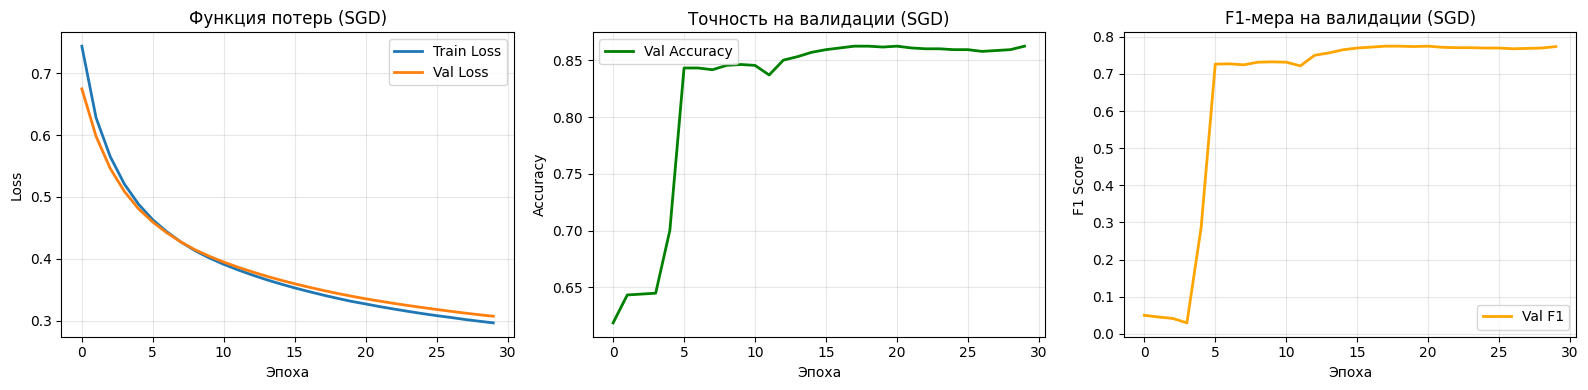

In [23]:
# ============================================================
# Визуализация обучения
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history_sgd['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_sgd['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь (SGD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_sgd['val_acc'], label='Val Accuracy', linewidth=2, color='green')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность на валидации (SGD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1
axes[2].plot(history_sgd['val_f1'], label='Val F1', linewidth=2, color='orange')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('F1-мера на валидации (SGD)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Оптимизатор Adam на чистом JAX

**Adam** (Adaptive Moment Estimation) — один из самых популярных оптимизаторов. Он сочетает:

1. **Momentum** (экспоненциальное скользящее среднее градиентов) — сглаживает направление
2. **RMSProp** (экспоненциальное скользящее среднее квадратов градиентов) — адаптивный learning rate

### Алгоритм Adam

$$m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t \quad \text{(первый момент — среднее градиентов)}$$
$$v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2 \quad \text{(второй момент — среднее квадратов)}$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t} \quad \text{(коррекция смещения)}$$
$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

### Почему Adam лучше SGD?

- **Адаптивный learning rate** — для каждого параметра свой, масштабированный по истории градиентов
- **Momentum** — не застревает в седловых точках
- **Коррекция смещения** — корректная работа на первых итерациях

In [24]:
# ============================================================
# Реализация Adam на чистом JAX
# ============================================================

def init_adam_state(params):
    """
    Инициализация состояния Adam.

    Состояние — это первый и второй моменты (m и v),
    инициализированные нулями, и счётчик шагов.

    Обратите внимание: состояние — иммутабельное.
    Каждый шаг создаёт НОВОЕ состояние.
    """
    # jax.tree.map — применяет функцию к каждому листу дерева параметров
    m = jax.tree.map(jnp.zeros_like, params)  # Первый момент
    v = jax.tree.map(jnp.zeros_like, params)  # Второй момент
    t = 0  # Счётчик шагов (для коррекции смещения)
    return (m, v, t)


def adam_update(params, grads, state, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Один шаг Adam.

    Чистая функция: принимает текущие params и state,
    возвращает новые params и state.

    Аргументы:
        params: текущие параметры сети
        grads: градиенты (той же структуры, что и params)
        state: (m, v, t) — состояние оптимизатора
        lr: learning rate (α)
        beta1: коэффициент для первого момента (обычно 0.9)
        beta2: коэффициент для второго момента (обычно 0.999)
        eps: малая константа для численной стабильности

    Возвращает:
        new_params, new_state
    """
    m, v, t = state
    t = t + 1  # Инкремент счётчика

    # Обновление моментов:
    # m_new = β1 * m + (1 - β1) * grad
    new_m = jax.tree.map(
        lambda mi, gi: beta1 * mi + (1 - beta1) * gi,
        m, grads
    )
    # v_new = β2 * v + (1 - β2) * grad^2
    new_v = jax.tree.map(
        lambda vi, gi: beta2 * vi + (1 - beta2) * gi ** 2,
        v, grads
    )

    # Коррекция смещения (bias correction)
    # На первых шагах m и v смещены к нулю — корректируем
    m_hat = jax.tree.map(lambda mi: mi / (1 - beta1 ** t), new_m)
    v_hat = jax.tree.map(lambda vi: vi / (1 - beta2 ** t), new_v)

    # Обновление параметров:
    # θ = θ - lr * m_hat / (sqrt(v_hat) + eps)
    new_params = jax.tree.map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat
    )

    return new_params, (new_m, new_v, t)


print("✅ Adam реализован на чистом JAX")
print("   - Функция init_adam_state: создаёт начальное состояние")
print("   - Функция adam_update: один шаг оптимизации")

✅ Adam реализован на чистом JAX
   - Функция init_adam_state: создаёт начальное состояние
   - Функция adam_update: один шаг оптимизации


In [25]:
# ============================================================
# Обучение с Adam
# ============================================================

@jax.jit
def train_step_adam(params, adam_state, x_batch, y_batch, lr):
    """
    Один шаг обучения с Adam.

    Заметьте: state передаётся явно и возвращается — нет
    скрытого мутабельного состояния!
    """
    loss, grads = jax.value_and_grad(loss_fn)(params, x_batch, y_batch)
    new_params, new_state = adam_update(params, grads, adam_state, lr=lr)
    return new_params, new_state, loss


# Инициализация
key = random.PRNGKey(42)
params_adam = init_network(key, layer_sizes)
adam_state = init_adam_state(params_adam)

learning_rate = 0.001
batch_size = 64
n_epochs = 50

history_adam = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

for epoch in range(n_epochs):
    key, subkey = random.split(key)
    batches = create_batches(subkey, X_train_jax, y_train_jax, batch_size)

    epoch_losses = []
    for x_batch, y_batch in batches:
        params_adam, adam_state, batch_loss = train_step_adam(
            params_adam, adam_state, x_batch, y_batch, learning_rate
        )
        epoch_losses.append(float(batch_loss))

    train_loss = np.mean(epoch_losses)
    val_metrics = compute_metrics(params_adam, X_val_jax, y_val_jax)

    history_adam['train_loss'].append(train_loss)
    history_adam['val_loss'].append(float(val_metrics['loss']))
    history_adam['val_acc'].append(float(val_metrics['accuracy']))
    history_adam['val_f1'].append(float(val_metrics['f1']))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:3d}/{n_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} | "
              f"Val Acc: {val_metrics['accuracy']:.4f} | "
              f"Val F1: {val_metrics['f1']:.4f}")

Эпоха   1/50 | Train Loss: 0.3201 | Val Loss: 0.2428 | Val Acc: 0.8978 | Val F1: 0.8411
Эпоха  10/50 | Train Loss: 0.1572 | Val Loss: 0.1782 | Val Acc: 0.9208 | Val F1: 0.8758
Эпоха  20/50 | Train Loss: 0.1366 | Val Loss: 0.1814 | Val Acc: 0.9224 | Val F1: 0.8779
Эпоха  30/50 | Train Loss: 0.1163 | Val Loss: 0.1873 | Val Acc: 0.9431 | Val F1: 0.9197
Эпоха  40/50 | Train Loss: 0.1173 | Val Loss: 0.1881 | Val Acc: 0.9293 | Val F1: 0.8933
Эпоха  50/50 | Train Loss: 0.1008 | Val Loss: 0.1867 | Val Acc: 0.9416 | Val F1: 0.9142


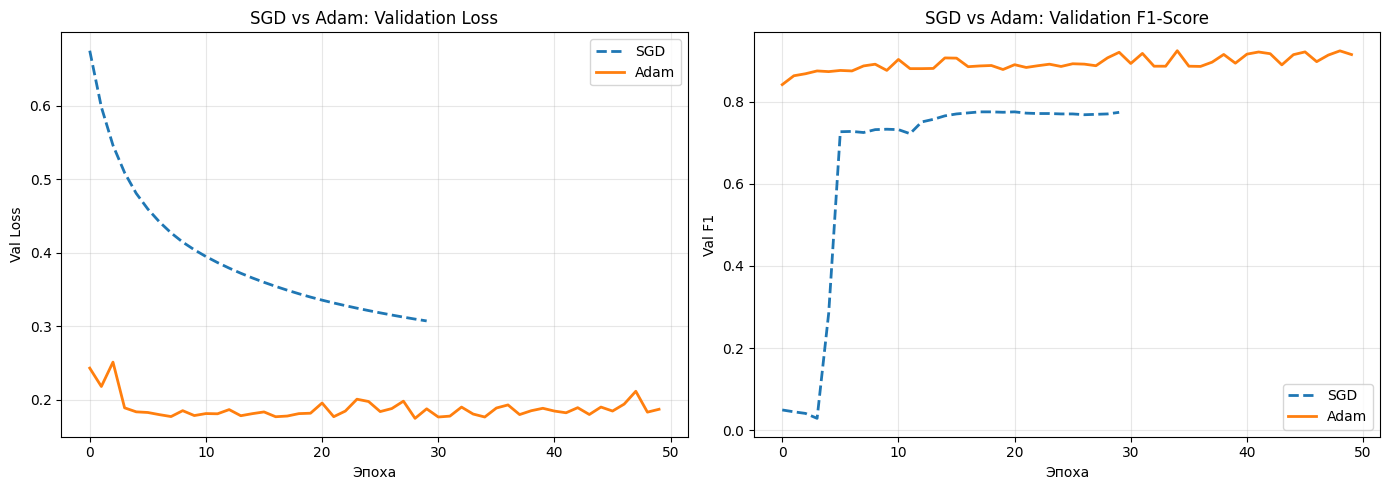

In [26]:
# ============================================================
# Сравнение SGD vs Adam
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сравнение Loss
axes[0].plot(history_sgd['val_loss'], label='SGD', linewidth=2, linestyle='--')
axes[0].plot(history_adam['val_loss'], label='Adam', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Val Loss')
axes[0].set_title('SGD vs Adam: Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Сравнение F1
axes[1].plot(history_sgd['val_f1'], label='SGD', linewidth=2, linestyle='--')
axes[1].plot(history_adam['val_f1'], label='Adam', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Val F1')
axes[1].set_title('SGD vs Adam: Validation F1-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 8. Борьба с переобучением

**Переобучение (overfitting)** — когда модель запоминает тренировочные данные вместо обобщения. Признак: train loss падает, а val loss растёт.

### Стратегии борьбы

| Метод | Идея | Реализация в JAX |
|-------|------|-----------------|
| **L2-регуляризация** | Штраф за большие веса: $\mathcal{L}_{total} = \mathcal{L} + \lambda \sum w_i^2$ | Добавляем к loss |
| **Dropout** | Случайно «выключаем» нейроны во время обучения | Маска через PRNG |
| **Ранняя остановка** | Прекращаем обучение, когда val loss перестаёт улучшаться | Мониторинг patience |

### L2-регуляризация (Weight Decay)

Добавляет штраф за «сложность» модели — большие веса. Это предотвращает слишком точное подстраивание под шум в данных.

### Dropout

Во время обучения случайно обнуляет часть нейронов (с вероятностью $p$). Это заставляет сеть не полагаться на отдельные нейроны и учиться более робастным признакам.

**Важно:** при inference (предсказании) dropout **выключается**, но выходы масштабируются на $(1-p)$, чтобы среднее значение осталось прежним. В нашей реализации мы используем «inverted dropout» — масштабируем во время обучения, чтобы при inference ничего менять не нужно.

### Ранняя остановка (Early Stopping)

Мониторим val loss: если он не улучшается `patience` эпох подряд — останавливаем обучение и откатываемся к лучшим весам.

In [27]:
# ============================================================
# L2-регуляризация
# ============================================================

def l2_regularization(params, lambda_reg):
    """
    Вычисляет L2-штраф: λ * Σ(w_i^2)

    Штрафуем только веса (W), НЕ смещения (b) — это стандартная практика,
    т.к. смещения не влияют на «сложность» модели.
    """
    l2_sum = 0.0
    for W, b in params:
        l2_sum += jnp.sum(W ** 2)  # Только веса, не bias
    return lambda_reg * l2_sum


def loss_fn_regularized(params, x, y, lambda_reg=0.001):
    """
    Loss + L2-регуляризация.

    L_total = BCE(logits, y) + λ * ||W||^2
    """
    logits = forward(params, x)
    data_loss = binary_cross_entropy_with_logits(logits, y)
    reg_loss = l2_regularization(params, lambda_reg)
    return data_loss + reg_loss


# Демонстрация эффекта регуляризации
test_params = init_network(random.PRNGKey(0), layer_sizes)
loss_no_reg = loss_fn(test_params, X_train_jax[:100], y_train_jax[:100])
loss_with_reg = loss_fn_regularized(test_params, X_train_jax[:100], y_train_jax[:100], lambda_reg=0.01)
print(f"Loss без регуляризации: {loss_no_reg:.4f}")
print(f"Loss с L2 (λ=0.01):     {loss_with_reg:.4f}")
print(f"Добавка от L2:           {loss_with_reg - loss_no_reg:.4f}")

Loss без регуляризации: 1.2783
Loss с L2 (λ=0.01):     5.7561
Добавка от L2:           4.4778


In [28]:
# ============================================================
# Dropout на чистом JAX
# ============================================================

from functools import partial
import jax.lax as lax

def dropout(key, x, drop_rate=0.5, training=True):
    """
    Inverted Dropout - JAX compatible version.

    Используем jax.lax.cond для работы с traced values.

    Во время обучения:
        - Генерируем случайную маску с вероятностью drop_rate
        - Масштабируем оставшиеся на 1/(1-drop_rate)

    Во время inference:
        - Возвращаем x без изменений
    """
    def apply_dropout(x):
        keep_rate = 1.0 - drop_rate
        mask = random.bernoulli(key, keep_rate, shape=x.shape).astype(x.dtype)
        return x * mask / keep_rate

    def identity(x):
        return x

    # JAX-compatible conditional - работает с traced values
    return lax.cond(
        training & (drop_rate > 0.0),
        apply_dropout,
        identity,
        x
    )


# Демонстрация dropout
key = random.PRNGKey(0)
x_demo = jnp.ones((1, 10))
print("Вход:        ", x_demo)
print("После dropout:", dropout(key, x_demo, drop_rate=0.5, training=True))
print("Inference:    ", dropout(key, x_demo, drop_rate=0.5, training=False))

Вход:         [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
После dropout: [[0. 0. 2. 2. 0. 2. 2. 0. 0. 2.]]
Inference:     [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]


In [29]:
# ============================================================
# Полная модель: forward с dropout и L2-регуляризацией
# ============================================================

def forward_with_dropout(params, x, key, drop_rate=0.3, training=True):
    """
    Forward pass с dropout после каждого скрытого слоя.

    Обратите внимание: key передаётся ЯВНО — чистая функция!
    Для каждого слоя нужен свой подключ.
    """
    n_layers = len(params)
    keys = random.split(key, n_layers - 1)  # Подключи для каждого скрытого слоя

    for i, (W, b) in enumerate(params[:-1]):
        x = x @ W + b
        x = jax.nn.relu(x)
        # Dropout после каждого скрытого слоя (НЕ после последнего!)
        x = dropout(keys[i], x, drop_rate=drop_rate, training=training)

    # Последний слой — без активации и без dropout
    W_last, b_last = params[-1]
    logits = (x @ W_last + b_last).squeeze(-1)
    return logits


def loss_fn_full(params, x, y, key, lambda_reg=0.001, drop_rate=0.3):
    """
    Полная функция потерь: BCE + L2 + Dropout.

    Все аргументы передаются явно — нет скрытого состояния.
    """
    logits = forward_with_dropout(params, x, key, drop_rate=drop_rate, training=True)
    data_loss = binary_cross_entropy_with_logits(logits, y)
    reg_loss = l2_regularization(params, lambda_reg)
    return data_loss + reg_loss


print("Модель с dropout и L2-регуляризацией готова")

Модель с dropout и L2-регуляризацией готова


In [30]:
# ============================================================
# Ранняя остановка (Early Stopping)
# ============================================================

class EarlyStopping:
    """
    Класс для ранней остановки обучения.

    Следит за val_loss: если он не улучшается patience эпох подряд,
    устанавливает флаг stop=True и сохраняет лучшие параметры.

    Примечание: это единственный мутабельный объект в нашем коде.
    Его нельзя передать в jit — он работает «снаружи» JAX.
    """
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience    # Сколько эпох ждать
        self.min_delta = min_delta  # Минимальное улучшение
        self.best_loss = float('inf')
        self.counter = 0
        self.best_params = None
        self.stop = False

    def check(self, val_loss, params):
        """
        Проверяет, нужно ли остановиться.

        Возвращает True, если нужно продолжить обучение.
        """
        if val_loss < self.best_loss - self.min_delta:
            # Улучшение! Сбрасываем счётчик.
            self.best_loss = val_loss
            self.counter = 0
            # Сохраняем копию лучших параметров
            self.best_params = jax.tree.map(lambda p: p.copy(), params)
        else:
            # Нет улучшения
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"Ранняя остановка! Лучший val_loss: {self.best_loss:.4f}")

        return not self.stop


print("EarlyStopping готов")

EarlyStopping готов


In [31]:
# ============================================================
# Финальное обучение: Adam + Dropout + L2 + Early Stopping
# ============================================================

@jax.jit
def train_step_full(params, adam_state, x_batch, y_batch, dropout_key, lr, lambda_reg, drop_rate):
    """
    Полный шаг обучения со всеми техниками регуляризации.
    """
    # value_and_grad вычисляет loss И градиенты за один проход
    loss, grads = jax.value_and_grad(loss_fn_full)(
        params, x_batch, y_batch, dropout_key, lambda_reg, drop_rate
    )
    new_params, new_state = adam_update(params, grads, adam_state, lr=lr)
    return new_params, new_state, loss


def compute_metrics_no_dropout(params, x, y):
    """
    Метрики БЕЗ dropout (inference mode).
    """
    logits = forward(params, x)  # Используем forward БЕЗ dropout
    loss = binary_cross_entropy_with_logits(logits, y)
    preds = (logits > 0.0).astype(jnp.float32)

    tp = jnp.sum(preds * y)
    fp = jnp.sum(preds * (1 - y))
    fn = jnp.sum((1 - preds) * y)

    accuracy = jnp.mean(preds == y)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {'loss': loss, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1}


# --- Гиперпараметры ---
learning_rate = 0.001
batch_size = 64
n_epochs = 200      # Максимум — ранняя остановка сработает раньше
lambda_reg = 0.0005  # Сила L2-регуляризации
drop_rate = 0.3      # Вероятность отключения нейрона
patience = 15        # Терпение для ранней остановки

# Инициализация
key = random.PRNGKey(42)
params_final = init_network(key, layer_sizes)
adam_state = init_adam_state(params_final)
early_stopping = EarlyStopping(patience=patience)

history_final = {'train_loss': [], 'val_loss': [], 'val_acc': [],
                 'val_f1': [], 'val_precision': [], 'val_recall': []}

print(f"Гиперпараметры:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  L2 lambda: {lambda_reg}")
print(f"  Dropout rate: {drop_rate}")
print(f"  Early stopping patience: {patience}")
print(f"  Max epochs: {n_epochs}")
print(f"\nНачинаем обучение...\n")

for epoch in range(n_epochs):
    # Новые ключи для перемешивания и dropout
    key, shuffle_key, dropout_key = random.split(key, 3)
    batches = create_batches(shuffle_key, X_train_jax, y_train_jax, batch_size)

    epoch_losses = []
    for i, (x_batch, y_batch) in enumerate(batches):
        # Уникальный ключ для dropout в каждом батче
        dropout_key, batch_dropout_key = random.split(dropout_key)
        params_final, adam_state, batch_loss = train_step_full(
            params_final, adam_state, x_batch, y_batch,
            batch_dropout_key, learning_rate, lambda_reg, drop_rate
        )
        epoch_losses.append(float(batch_loss))

    # Метрики (БЕЗ dropout!)
    train_loss = np.mean(epoch_losses)
    val_metrics = compute_metrics_no_dropout(params_final, X_val_jax, y_val_jax)

    history_final['train_loss'].append(train_loss)
    history_final['val_loss'].append(float(val_metrics['loss']))
    history_final['val_acc'].append(float(val_metrics['accuracy']))
    history_final['val_f1'].append(float(val_metrics['f1']))
    history_final['val_precision'].append(float(val_metrics['precision']))
    history_final['val_recall'].append(float(val_metrics['recall']))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Эпоха {epoch+1:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_metrics['loss']:.4f} | "
              f"Acc: {val_metrics['accuracy']:.4f} | "
              f"F1: {val_metrics['f1']:.4f} | "
              f"P: {val_metrics['precision']:.4f} | "
              f"R: {val_metrics['recall']:.4f}")

    # Проверка ранней остановки
    if not early_stopping.check(float(val_metrics['loss']), params_final):
        print(f"Остановка на эпохе {epoch + 1}")
        break

# Восстанавливаем лучшие параметры
if early_stopping.best_params is not None:
    params_final = early_stopping.best_params
    print("Восстановлены лучшие веса")

Гиперпараметры:
  Learning rate: 0.001
  Batch size: 64
  L2 lambda: 0.0005
  Dropout rate: 0.3
  Early stopping patience: 15
  Max epochs: 200

Начинаем обучение...

Эпоха   1/200 | Train: 0.6741 | Val: 0.2980 | Acc: 0.8847 | F1: 0.8188 | P: 0.8851 | R: 0.7618
Эпоха  10/200 | Train: 0.3452 | Val: 0.1925 | Acc: 0.9178 | F1: 0.8712 | P: 0.9378 | R: 0.8135
Эпоха  20/200 | Train: 0.2640 | Val: 0.1858 | Acc: 0.9216 | F1: 0.8768 | P: 0.9478 | R: 0.8157
Эпоха  30/200 | Train: 0.2360 | Val: 0.1869 | Acc: 0.9231 | F1: 0.8943 | P: 0.8443 | R: 0.9506
Ранняя остановка! Лучший val_loss: 0.1786
Остановка на эпохе 34
Восстановлены лучшие веса


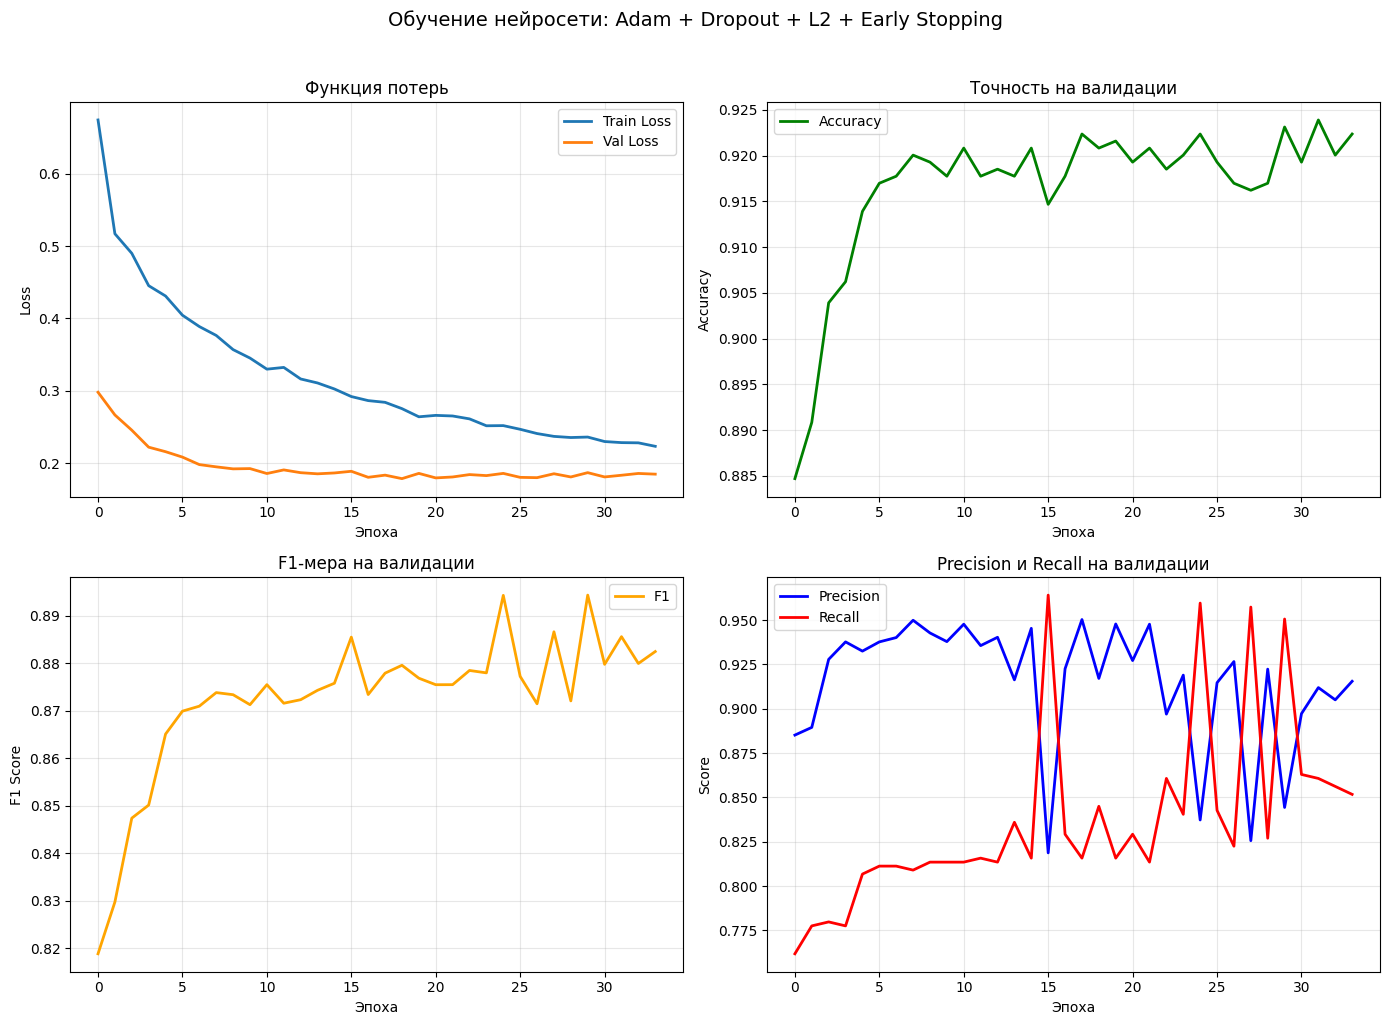

In [32]:
# ============================================================
# Визуализация финального обучения
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history_final['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history_final['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Функция потерь')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history_final['val_acc'], label='Accuracy', linewidth=2, color='green')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Точность на валидации')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1
axes[1, 0].plot(history_final['val_f1'], label='F1', linewidth=2, color='orange')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('F1-мера на валидации')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision / Recall
axes[1, 1].plot(history_final['val_precision'], label='Precision', linewidth=2, color='blue')
axes[1, 1].plot(history_final['val_recall'], label='Recall', linewidth=2, color='red')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision и Recall на валидации')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Обучение нейросети: Adam + Dropout + L2 + Early Stopping', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# Оценка на тестовой выборке
# ============================================================

test_metrics = compute_metrics_no_dropout(params_final, X_test_jax, y_test_jax)

print("=" * 50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"  Loss:      {test_metrics['loss']:.4f}")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall:    {test_metrics['recall']:.4f}")
print(f"  F1-Score:  {test_metrics['f1']:.4f}")
print("=" * 50)

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
  Loss:      0.1492
  Accuracy:  0.9247
  Precision: 0.9263
  Recall:    0.8472
  F1-Score:  0.8850


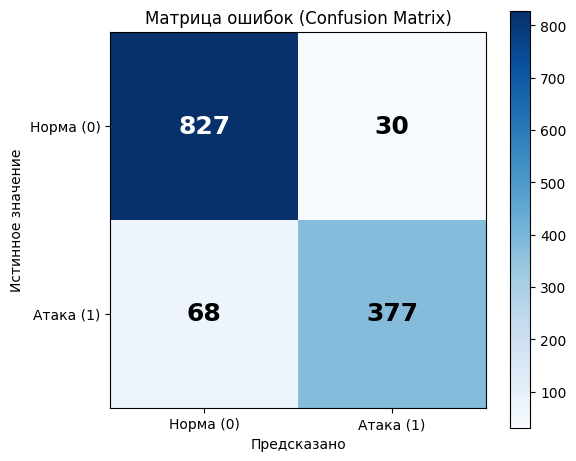


True Negatives (верно — норма):  827
True Positives (верно — атака):  377
False Positives (ложная тревога): 30
False Negatives (пропуск атаки):  68


In [34]:
# ============================================================
# Confusion Matrix — матрица ошибок
# ============================================================

logits_test = forward(params_final, X_test_jax)
preds_test = (logits_test > 0.0).astype(jnp.float32)

# Вычисляем матрицу ошибок
tp = int(jnp.sum(preds_test * y_test_jax))
tn = int(jnp.sum((1 - preds_test) * (1 - y_test_jax)))
fp = int(jnp.sum(preds_test * (1 - y_test_jax)))
fn = int(jnp.sum((1 - preds_test) * y_test_jax))

# Визуализация
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap='Blues')

# Подписи
labels = ['Норма (0)', 'Атака (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинное значение')
ax.set_title('Матрица ошибок (Confusion Matrix)')

# Числа в ячейках
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold', color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (верно — норма):  {tn}")
print(f"True Positives (верно — атака):  {tp}")
print(f"False Positives (ложная тревога): {fp}")
print(f"False Negatives (пропуск атаки):  {fn}")

---
## Итоги

### Что мы сделали

1. **Функциональное программирование** — изучили принципы чистых функций, иммутабельности, композиции. Эти принципы лежат в основе JAX.

2. **JAX** — освоили ключевые трансформации: `grad` (дифференцирование), `jit` (компиляция), `vmap` (векторизация). Научились «думать в JAX»: явный PRNG, иммутабельные массивы, чистые функции.

3. **Forward vs Reverse mode** — поняли, почему backpropagation (reverse mode) эффективен для нейросетей: один проход назад даёт градиенты по ВСЕМ параметрам.

4. **Предобработка** — очистили данные, разделили на train/val/test, стандартизировали (только по train-статистикам!).

5. **Нейросеть** — построили с нуля на чистом JAX: инициализация He, forward pass, binary cross-entropy.

6. **Обучение** — реализовали mini-batch gradient descent с мониторингом метрик.

7. **Adam** — реализовали с нуля: моменты, коррекция смещения, адаптивный learning rate.

8. **Борьба с переобучением** — L2-регуляризация, dropout (inverted), ранняя остановка.

### Главные уроки

- **JAX поощряет чистый функциональный стиль** — это делает код предсказуемым и совместимым с трансформациями.
- **Явная передача состояния** — вместо скрытых мутаций мы всегда знаем, что входит и что выходит из функции.
- **Регуляризация необходима** — без неё модель быстро переобучается, особенно на небольших датасетах.
- **Мониторинг — ключ к успеху** — без графиков и метрик мы слепы.